# EDA Exploration — Superstore Sales

**Author:** Eman Mahmoud
**Input:** `data/superstore_clean.csv`
**Goal:** Day 16 EDA before main analysis — distributions, top categories, trends, outliers.

> This notebook supports `Superstore_Analysis.ipynb`. Keep it exploratory; the polished charts go in the main notebook.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## Load Cleaned Data

In [2]:
df = pd.read_csv("../data/superstore_clean.csv", parse_dates=["Order Date", "Ship Date"])
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 9994 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Overview — dtypes, missing values, describe

In [3]:
print(df.dtypes)
print()
print(df.describe())
print()
print(df.isnull().sum())

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

            Row ID                  Order Date                   Ship Date  \
count  9994.000000                        9994                        9994   
mean   4997.500000  2016-04-30 00:07:12.259355  2016-05-03 23:06:58.571142   
min       1.000000         2014-01-03 00:00:00         2014-01-07 00:00:00   
2

## EDA 1 — Distribution of Sales, Profit, Discount

Histograms / describe to see skew and spread.

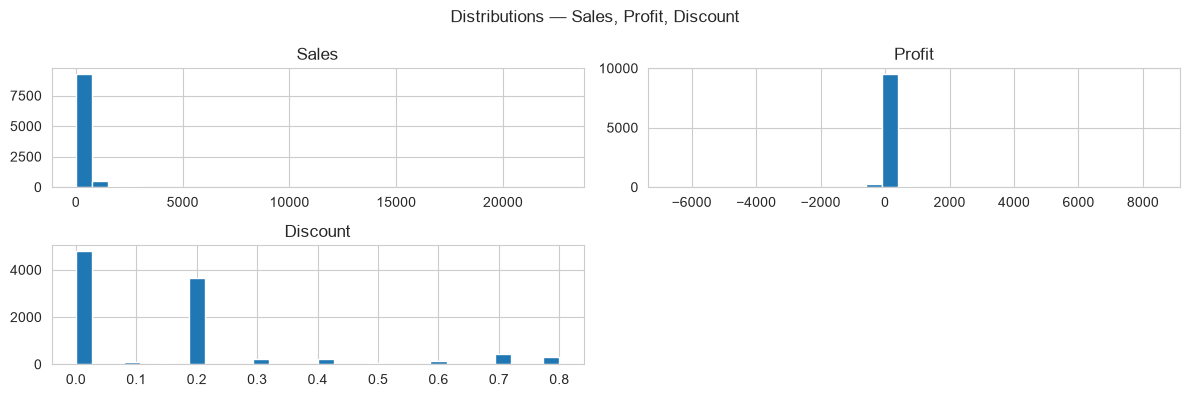

              Sales       Profit     Discount
count   9994.000000  9994.000000  9994.000000
mean     229.858001    28.656896     0.156203
std      623.245101   234.260108     0.206452
min        0.444000 -6599.978000     0.000000
25%       17.280000     1.728750     0.000000
50%       54.490000     8.666500     0.200000
75%      209.940000    29.364000     0.200000
max    22638.480000  8399.976000     0.800000


In [4]:
#Distributions
df[["Sales", "Profit", "Discount"]].hist(bins=30, figsize=(12,4))
plt.suptitle("Distributions — Sales, Profit, Discount")
plt.tight_layout()
plt.show()
print(df[["Sales", "Profit", "Discount"]].describe())

## EDA 2 — Top Categories and Sub-Categories

Bar charts for sales/profit by Category and Sub-Category.

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


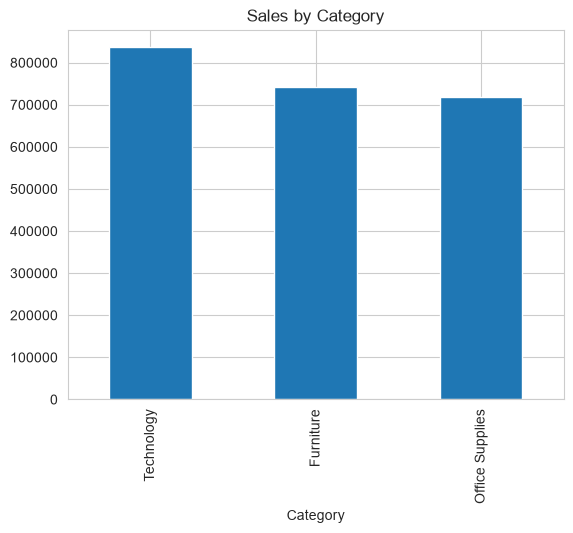

In [5]:
#Top categories
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
cat_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print(cat_sales)
print(cat_profit)
cat_sales.plot(kind="bar", title="Sales by Category")
plt.show()

## EDA 3 — Sales and Profit Over Time

Line chart monthly — check trend and seasonality.

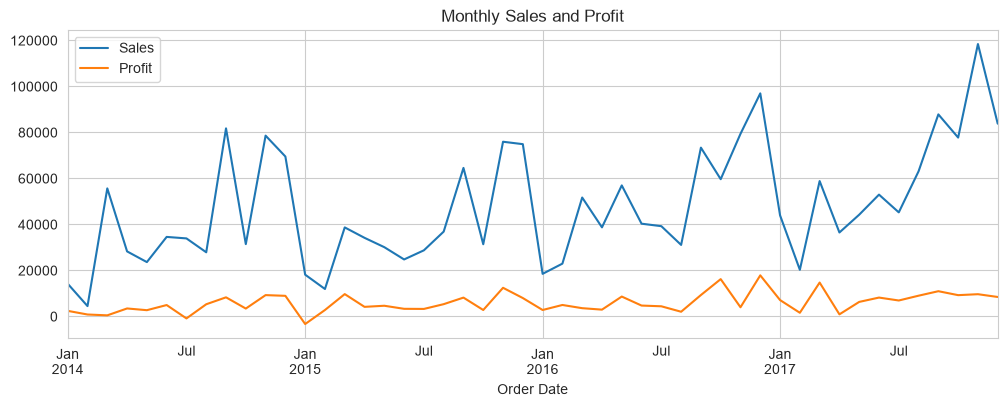

In [6]:
monthly = df.groupby(pd.Grouper(key="Order Date", freq="ME"))[["Sales", "Profit"]].sum()
monthly.plot(figsize=(12,4), title="Monthly Sales and Profit")
plt.show()

## EDA 4 — Outliers in Sales and Profit

Boxplot + IQR check — which orders disproportionately affect totals?

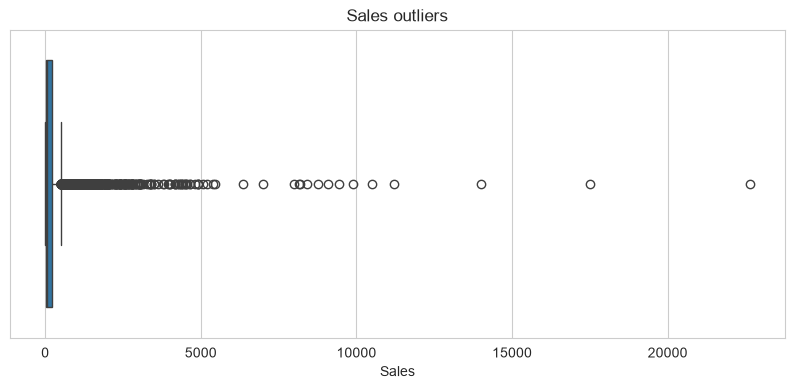

Sales upper fence: 498.93, outliers: 1167


In [7]:
#Outliers
plt.figure(figsize=(10,4))
sns.boxplot(x=df["Sales"])
plt.title("Sales outliers")
plt.show()
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
upper = Q3 + 1.5*(Q3-Q1)
print(f"Sales upper fence: {upper:.2f}, outliers: {(df['Sales'] > upper).sum()}")

## EDA 5 — Correlation Check

Scatter + correlation between Discount and Profit (supports Q3).

          Discount    Profit     Sales
Discount  1.000000 -0.219487 -0.028190
Profit   -0.219487  1.000000  0.479064
Sales    -0.028190  0.479064  1.000000


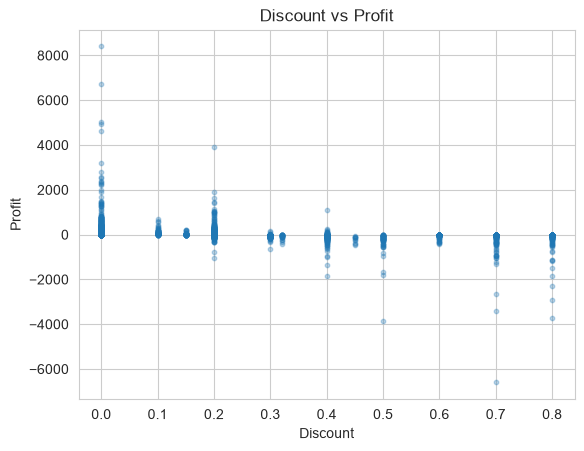

In [8]:
print(df[["Discount", "Profit", "Sales"]].corr())
plt.scatter(df["Discount"], df["Profit"], alpha=0.3, s=10)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

## EDA Summary

- Sales and Profit are heavily right-skewed — most orders are small (median 
Sales ≈ $54), with a small number of large orders pulling the mean up 
(mean ≈ $230). This motivated the outlier analysis in the main notebook.
- Discount is not continuous — it clusters at specific levels (0%, 20%, 
and smaller spikes at 30-80%), suggesting a tiered discount policy rather 
than freeform discounting.
- Technology leads in both sales and profit, while Furniture has strong 
sales but very weak profit — this divergence shaped Analysis Question 1.
- Monthly sales/profit show clear year-end seasonality (low in January, 
peak in Nov/Dec each year) — this shaped Analysis Question 2 and the 
choice of a line chart.
- Discount and Profit show a weak overall correlation (-0.22), but a 
clear threshold appears around 20% discount, where average profit turns 
negative — this shaped Analysis Question 3 and the decision to use 
discount bins, not just a raw scatter plot.
- ~11.7% of orders are Sales outliers, contributing roughly two-thirds of 
total sales — concentrated in Furniture, linking back to its weak margin.